In [1]:
!pip install xgboost
!pip install --upgrade scikit-learn

In [2]:
# Import necessary libraries

# For data Analysis
import pandas as pd
import numpy as np

In [3]:
# For data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Data pre-processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [5]:
# Classifier Libraries
import sklearn
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [6]:
# !pip install xgboost
from xgboost import XGBClassifier  # Corrected capitalization
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [7]:
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
# Load the data set
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [12]:
# Data verification - Data type, number of features and rows, missing data, etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [13]:
# Statistical Analysis of the data
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [14]:
#Check for missing values
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


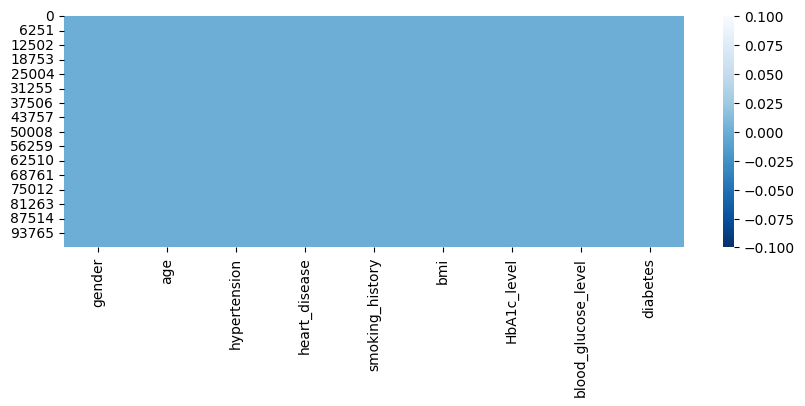

In [15]:
#Visualizing the missing data
plt.figure(figsize = (10,3))
sns.heatmap(df.isnull(), cbar=True, cmap="Blues_r");

**Exploratory Data Analysis**

**Univariate Analysis**

In [16]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

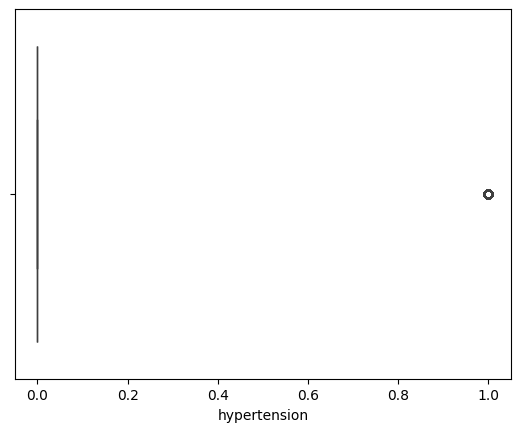

In [17]:
# Check for outliers
sns.boxplot(x=df["hypertension"]);

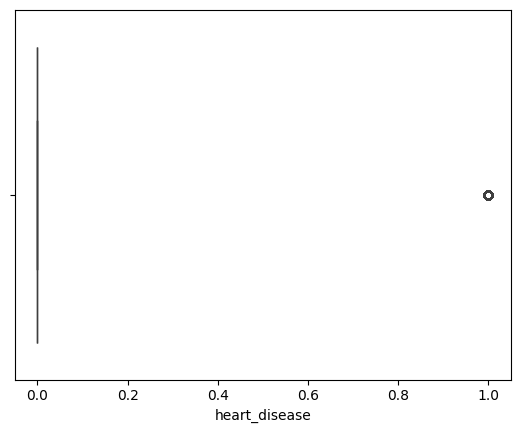

In [18]:
# check for outliers
sns.boxplot(x=df["heart_disease"]);

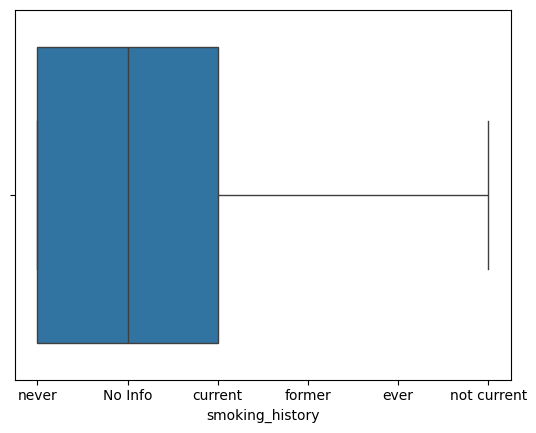

In [19]:
# check for outliers
sns.boxplot(x=df["smoking_history"]);


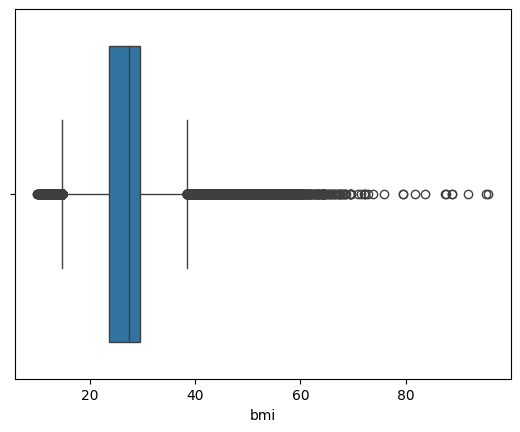

In [20]:
# checking for outliers
sns.boxplot(x=df["bmi"]);

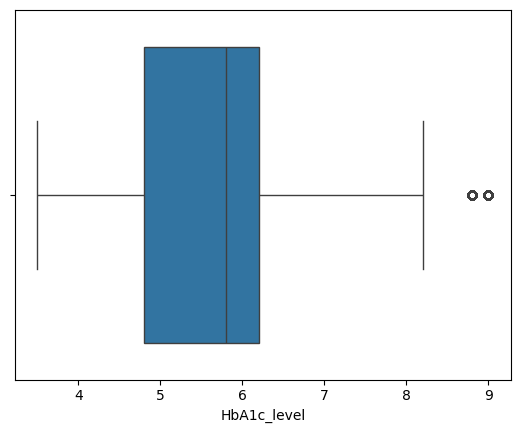

In [21]:
# checking for outliers
sns.boxplot(x=df["HbA1c_level"]);



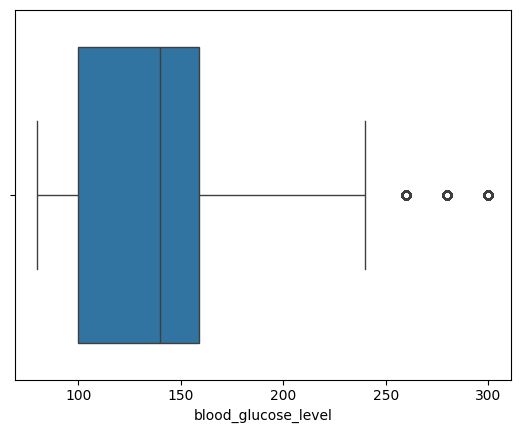

In [22]:
# checking for outlier
sns.boxplot(x=df["blood_glucose_level"]);

In [24]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [25]:
#Data Visualization
#Age_bracket
def age_bracket(age):
    if age <= 35:
        return "youth(<=35)"
    elif age <= 55:
        return "Adult(<=55)"
    elif age <= 65:
        return "old Adult(<=65)"
    else:
        return "Elderly(>65)"
df["age_bracket"] = df["age"].apply(age_bracket)




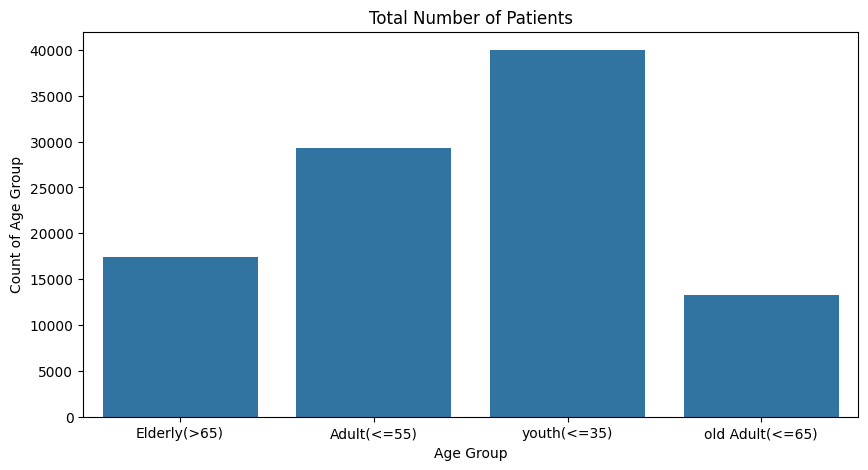

In [26]:
#Investigating the age group of patients
plt.figure(figsize = (10,5))
sns.countplot(x="age_bracket", data=df)
plt.xlabel("Age Group")
plt.ylabel("Count of Age Group")
plt.title("Total Number of Patients");

In [29]:
# Assuming the column name is actually 'gender' and not 'sex'
# If it's named differently replace 'gender' with the actual column name
def gender(sex):
    if sex ==1:
        return "Male"
    else:
        return "Female"
df["gender"] = df["gender"].apply(gender)


# Replace "Male" with 1 and "Female" with 2
df["gender"] = df["gender"].map({"Male": 1, "Female": 2})

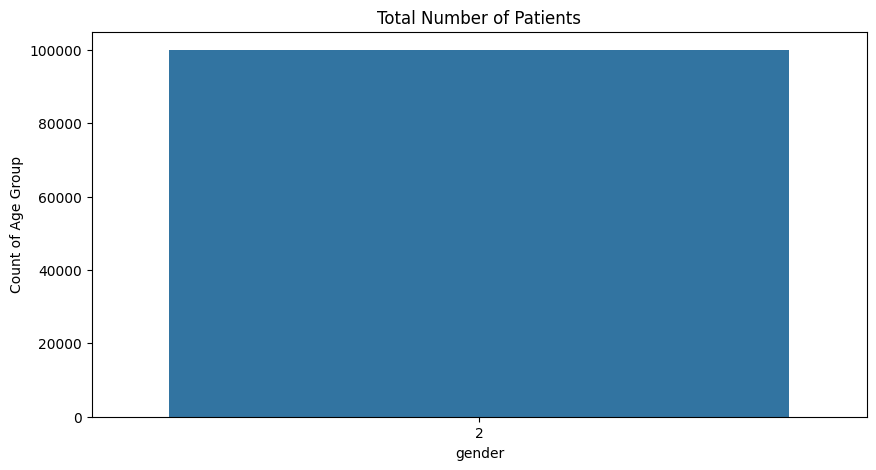

In [31]:
# investigating the age groups ot patients male and female
plt.figure(figsize = (10,5))
sns.countplot(x="gender", data=df)
plt.xlabel("gender")
plt.ylabel("Count of Age Group")
plt.title("Total Number of Patients");

In [32]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_bracket'],
      dtype='object')

In [33]:
# Convert categorical columns if necessary
df['gender'] = df['gender'].astype(str)
df['smoking_history'] = df['smoking_history'].astype(str)


In [34]:
# Set style
sns.set(style='whitegrid')

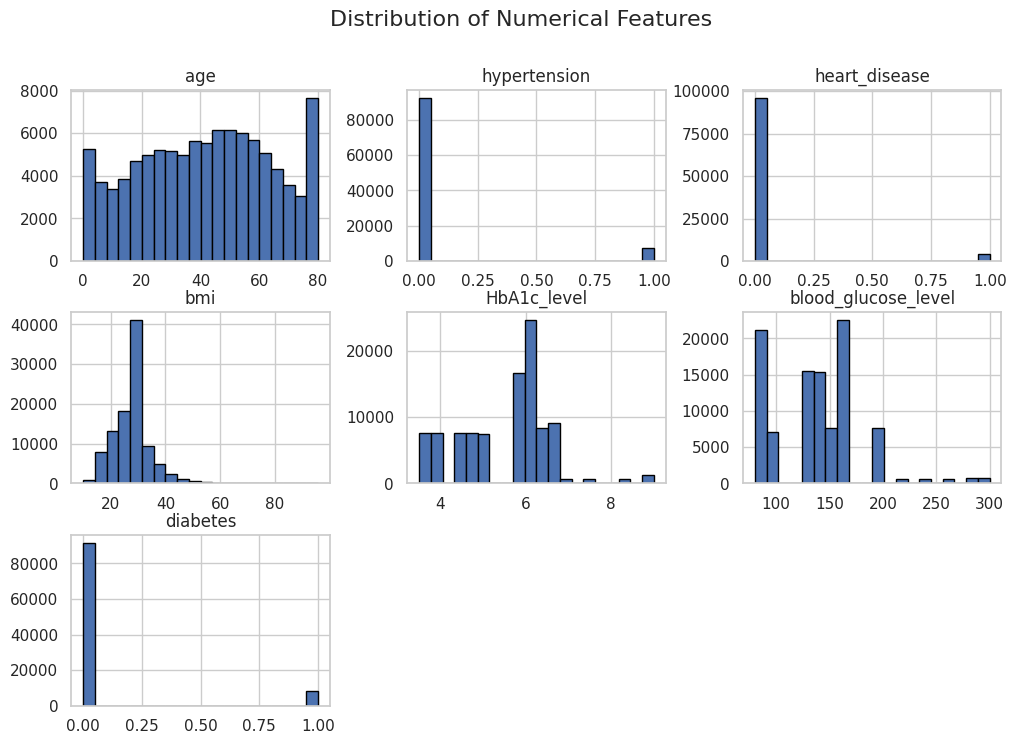

In [35]:
# Histograms for numerical features
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

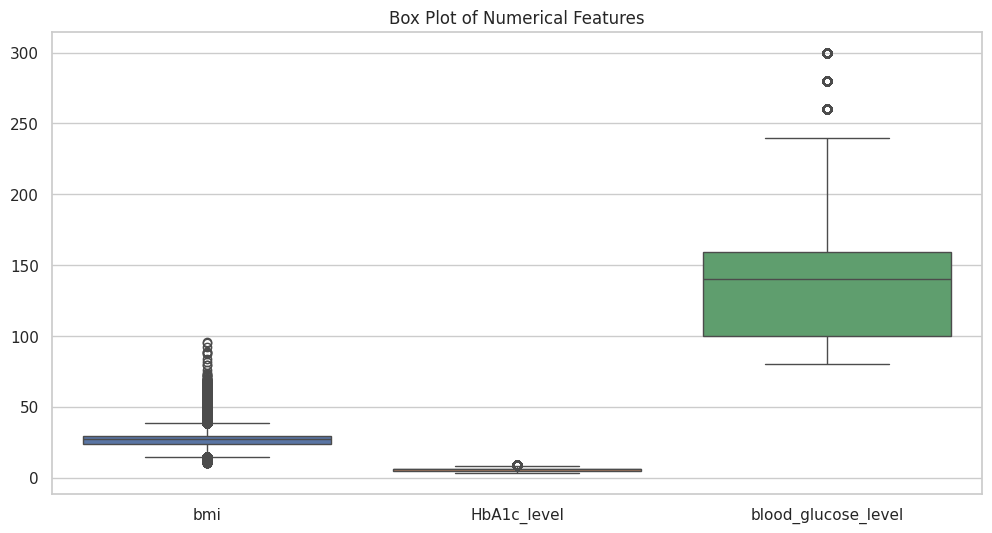

In [36]:
# Box plots for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['bmi', 'HbA1c_level', 'blood_glucose_level']])
plt.title('Box Plot of Numerical Features')
plt.show()


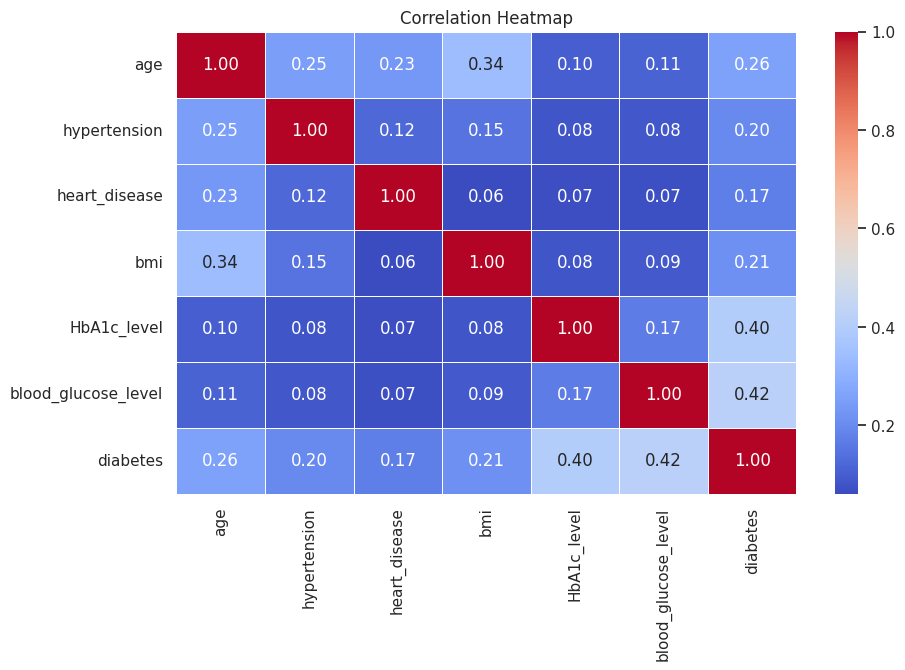

In [38]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

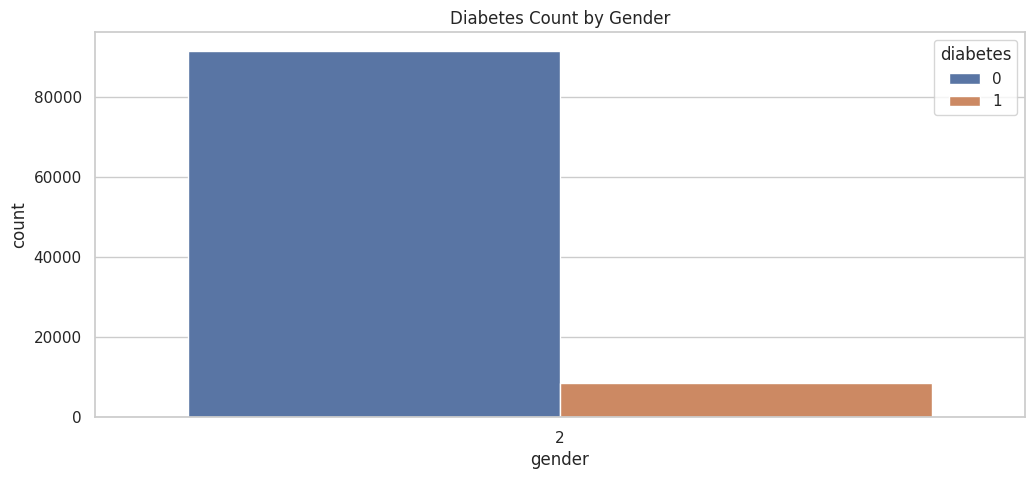

In [39]:
# Bar plots for categorical features
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='gender', hue='diabetes')
plt.title('Diabetes Count by Gender')
plt.show()

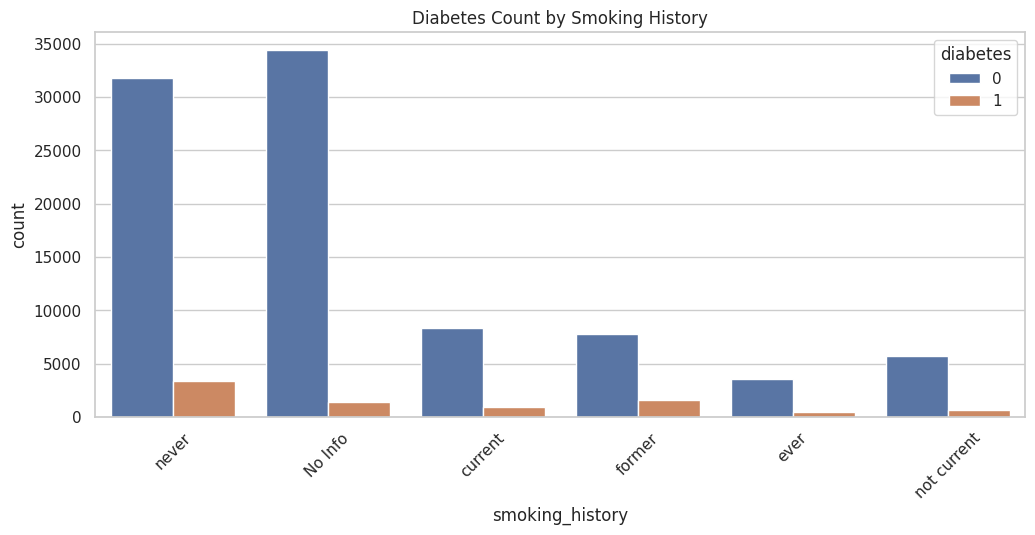

In [40]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='smoking_history', hue='diabetes')
plt.title('Diabetes Count by Smoking History')
plt.xticks(rotation=45)
plt.show()

In [41]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [42]:
# Convert categorical columns
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df['smoking_history'] = LabelEncoder().fit_transform(df['smoking_history'].astype(str))

In [43]:
# Splitting data into features and target
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Convert categorical columns to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['age_bracket', 'smoking_history'], drop_first=True)

# Splitting data into features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# Model Training & Evaluation
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True),
    'Neural Network': MLPClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.87      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.92      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000

[[18132   160]
 [  652  1056]]
--- Random Forest ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.94      0.69      0.79      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000

[[18219    73]
 [  533  1175]]
--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       0.99      0.69      0.81      1708

    accuracy                           0.97 

Observations, Interpretation, and Narration for Model Performance
Observations
Overall Model Performance

Most models achieved a high accuracy (~96-97%), indicating strong performance.
However, recall for class 1 (diabetes cases) is lower across all models, meaning some diabetic cases are being misclassified as non-diabetic.
Model Comparisons

Best Recall for Class 1 (Diabetes Cases):
Gradient Boosting (69%)
Neural Network (69%)
Random Forest (69%)
These models are better at detecting diabetic cases compared to others.
Best Overall F1-Score for Class 1:
Gradient Boosting (81%)
Neural Network (81%)
Random Forest (79%)
SVM Performs Worst on Class 1:
Lowest recall (56%), meaning it misses more actual diabetic cases.
Logistic Regression Struggles with Class 1:
Recall of 62%, meaning many actual diabetic cases are classified as non-diabetic.
Confusion Matrix Insights

The number of false negatives (diabetic patients misclassified as non-diabetic) is highest in Logistic Regression and SVM.
Gradient Boosting and Neural Network have the lowest false negatives, making them the best choices.
Interpretation
Gradient Boosting and Neural Network Are the Best Choices

They balance precision and recall well, with a high f1-score of 81% for diabetes cases.
Low false negatives, meaning they identify more actual diabetic cases correctly.
Accuracy (97%) and AUC (0.98) confirm their superiority.
Random Forest is Strong But Slightly Inferior

Has slightly lower recall (69%) than Gradient Boosting and Neural Network.
Still a good choice, especially for interpretability.
Logistic Regression and SVM Are Less Effective

Lower recall (Logistic Regression: 62%, SVM: 56%) means many diabetic cases are misclassified.
SVM has the worst recall, making it less ideal for this task.
Importance of Recall for Diabetes Prediction

Since false negatives (undiagnosed diabetes cases) are critical, models with higher recall are preferred.
Gradient Boosting and Neural Networks should be prioritized for deployment.
Narration
"The model evaluation highlights Gradient Boosting and Neural Networks as the best models for predicting diabetes. These models strike a balance between high accuracy (97%) and strong recall (69%), making them highly effective in identifying diabetic patients. Random Forest also performs well, though slightly below the top models. In contrast, Logistic Regression and SVM struggle with recall (62% and 56%, respectively), meaning they misclassify more diabetic patients as non-diabetic. Given the importance of early diabetes detection, Gradient Boosting and Neural Networks are the most suitable choices for real-world application."

Would you like further recommendations on model improvements, feature engineering, or deployment strategies? 🚀

In [49]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best parameters for Random Forest:", grid_search.best_params_)

Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}


Observations
Hyperparameter tuning was conducted using GridSearchCV

The parameters tuned include:
n_estimators (Number of trees in the forest): 50, 100, 200
max_depth (Maximum depth of trees): None, 10, 20
min_samples_split (Minimum samples required to split a node): 2, 5, 10
A 5-fold cross-validation (cv=5) was used to evaluate model performance.
Best Parameters Identified

max_depth: None (Indicating the model performed best when trees were fully expanded).
min_samples_split: 10 (A higher value means trees were pruned more aggressively to prevent overfitting).
n_estimators: 50 (A smaller number of trees resulted in optimal performance, suggesting diminishing returns from more trees).
Trade-off Between Model Complexity and Performance

A higher min_samples_split (10) suggests that limiting tree splits improved model generalization and reduced overfitting.
Using fewer estimators (n_estimators=50) suggests that increasing the number of trees beyond this did not significantly improve accuracy.
Unrestricted tree depth (max_depth=None) means deep trees contributed to strong model performance.
Interpretation
The best parameters found (max_depth=None, min_samples_split=10, n_estimators=50) indicate that a simpler Random Forest model with fewer trees but well-optimized splits provided the best accuracy.
The fact that min_samples_split=10 was chosen suggests the model benefits from regularization, preventing excessive branching that could lead to overfitting.
Since n_estimators=50 was optimal, increasing the number of trees beyond this likely led to only marginal improvements, while increasing computation time unnecessarily.
The absence of a max depth limit (max_depth=None) implies that deep trees were useful, but the chosen min_samples_split=10 prevented over-complexity.
Narration
"The hyperparameter tuning process for the Random Forest model revealed that the optimal configuration involves 50 trees (n_estimators=50), unrestricted tree depth (max_depth=None), and a minimum of 10 samples required to split a node (min_samples_split=10). These settings suggest that while deep trees contribute positively to model performance, controlling the number of splits helps prevent overfitting. Interestingly, the model did not benefit significantly from adding more trees beyond 50, highlighting a balance between computational efficiency and predictive power. The results indicate that a well-regularized but deep tree-based model provides the best accuracy for diabetes prediction."

Would you like to run hyperparameter tuning on other models, such as Gradient Boosting or XGBoost?

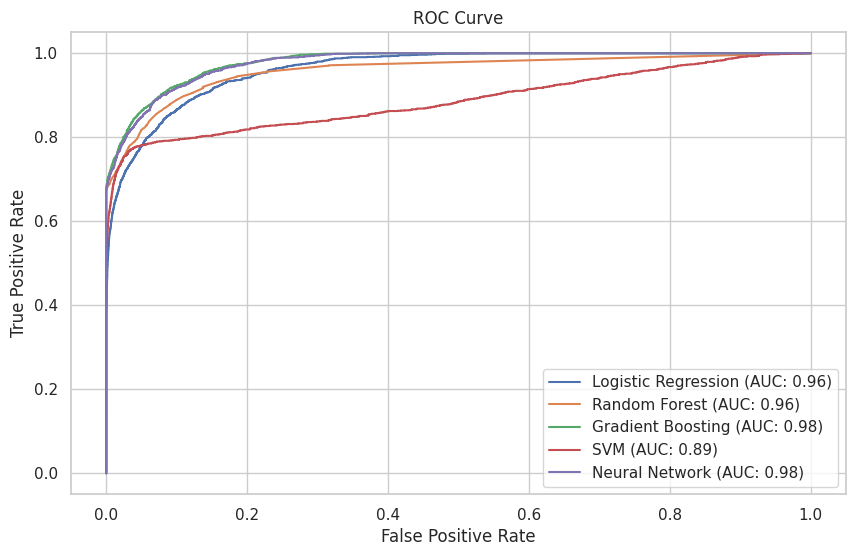

In [50]:
# ROC Curve
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC: {auc(fpr, tpr):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Observations and Narrations from the ROC Curve Analysis
Observations
Neural Network and Gradient Boosting Perform Best

Both models achieved an AUC score of 0.98, indicating exceptional performance in distinguishing between diabetic and non-diabetic patients.
Their ROC curves are closest to the top-left corner, meaning they have high sensitivity (true positive rate) and low false positive rate.
Logistic Regression and Random Forest Are Strong Contenders

Both models have AUC scores of 0.96, showing strong predictive power.
These models are nearly as good as Gradient Boosting and Neural Networks, making them reliable choices for diabetes prediction.
SVM Underperforms Compared to Other Models

AUC of 0.89, which is notably lower than the other models.
Its ROC curve does not rise as steeply as others, meaning it struggles with false positives or false negatives compared to higher-performing models.
Models with Higher AUC Offer Better Predictions

The closer AUC is to 1.0, the better the model's ability to differentiate diabetic and non-diabetic cases.
AUC above 0.95 is considered excellent, meaning most models in this comparison perform well.